# SULO Pizza Tutorial — Processes

# Learning objectives

* Represent processes, their participants, and the roles they play
* Order processes using both relative and absolute time
* Understand when objects cease to exist and when they continue existing

# Processes
In the previous notebooks we built an ontology of *objects*: spatial objects like pizzas and their parts, qualities like spiciness, and quantities that measure them. But the world is not only made of objects — it is also made of **processes, events, activities, and transformations** that bring objects into existence, modify them, and destroy them.

A pizza is never simply *there*. It is the outcome of a sequence of deliberate acts: flour and water are mixed into dough, the dough is left to ferment, sauce and cheese are spread on the flattened base, the whole is placed in a hot oven, and the baked result is cut into slices. Each of these acts is a **process** — a temporally extended event involving participants that may be created, changed, or consumed along the way.

Representing processes explicitly matters for several reasons:

- **Provenance**: knowing *how* an object came to be tells us about its properties and history (e.g., a slow-fermented dough has different qualities than one rushed through proofing).
- **Identity and continuity**: some processes preserve the identity of their participants (a dough is still the same dough after proofing), while others destroy existing objects and create new ones (the dough that enters an oven is not the same kind of object as the crust that comes out). Making this distinction precise is one of the central challenges in ontology engineering.

SULO provides a `Process` class and the temporal relation `precedes` as a foundation. In this notebook we extend that foundation with a small **sulo-ext** ontology that introduces process sub-types (`TransformationProcess`, `DevelopmentalProcess`, `CompositionProcess`, `DecompositionProcess`) and participant properties (`hasDirectParticipant`, `hasOutput`, `hasAgent`), and we apply them to model the full pipeline of making a pizza from raw ingredients to sliced result.

In [1]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()  # RDF/XML
pizza = get_ontology("dist/pizza-02.owl").load()
pizza.imported_ontologies.append(sulo)

In [2]:
base_iri = "https://w3id.org/ontostart/sulo-ext/"
se = get_ontology(base_iri)
    
with se:
    ## Object Properties
    class hasDirectParticipant(sulo.hasParticipant):
        """A property that relates a process to its direct participants. Used for cardinality constraints on process participants."""
        pass


    ## Process Classes
    class DevelopmentalProcess(sulo.Process):
        """A process that brings about changes in the qualities, states, or configurations of an existing object without altering its identity or kind."""
        pass
    class TransformationProcess(sulo.Process):
        """A process that transforms an input entity into an output entity of a different kind or identity."""
        pass
    class CompositionProcess(sulo.Process):
        """A process that results in the creation of a new entity by combining multiple input entities."""
        pass
    class DecompositionProcess(sulo.Process):
        """A process that results in the breakdown of an entity into its constituent parts."""
        pass
    
    ### Role Classes
    class InputRole(sulo.Role):
        """A role played by an entity that serves as an input to a process."""
        pass

    class AgentRole(InputRole):
        """A role played by an entity that intentionally brings about a process."""
        pass

    class TargetRole(InputRole):
        """A role played by an entity that is affected or transformed by a process."""
        pass

    class InstrumentRole(InputRole):
        """A role played by an entity that serves as an instrument in a process."""
        pass
            
    class OutputRole(sulo.Role):
        """A role played by an entity that serves as an output of a process."""
        pass
    
pizza.comment = "An ontology to represent pizzas using the SULO ontology."

# save this file
se.save("sulo-ext.owl", format="rdfxml")

pizza.imported_ontologies.append(se)

## Making the Pizza Dough — a Transformation Process

Pizza dough is made by combining **flour**, **water**, **sugar**, **baker's yeast**, and **salt** and working them together until a uniform, elastic mass forms. Each ingredient is a distinct food material with its own identity and composition. Once combined and kneaded, those separate materials **cease to exist** as independent entities and a new kind of object — `PizzaDough` — comes into being.

This is why we model it as a `TransformationProcess`: the inputs are consumed and destroyed, and the output is a new individual of a different kind. It contrasts directly with `ProofingTheDough` (coming next), where the dough persists and only its qualities change.

We use the `se:hasDirectParticipant` sub-property of `se:hasDirectParticipant` to relate the process to each ingredient, and `se:hasOutput` to relate it to the resulting dough. Cardinality restrictions (`exactly 1`) express that a single batch of each ingredient is consumed to yield exactly one dough.

> **Note:** Two alternative modellings are shown below. The first (`MakingThePizzaDough`) relates the process directly to ingredient *classes*. The second (`MakingThePizzaDough_v2`) relates it to *roles* — reified as `InputRole` and `OutputRole` instances that are features of the participants. The role-based approach is more semantically precise but more complex; both are valid OWL patterns.

In [3]:
with pizza:
    class Flour(pizza.FoodMaterial):
        pass

    class Water(pizza.FoodMaterial):
        pass

    class Sugar(pizza.FoodMaterial):
        pass
    
    class BakersYeast(pizza.FoodMaterial):
        pass

    class Salt(pizza.FoodMaterial):
        pass

    class PizzaDough(pizza.FoodMaterial):
        pass

In [4]:
with pizza:
    class MakingThePizzaDough(sulo.Process  ):
        is_a = [sulo.Process
                & se.hasDirectParticipant.exactly(1, Flour)
                & se.hasDirectParticipant.exactly(1, Water)
                & se.hasDirectParticipant.exactly(1, Sugar)
                & se.hasDirectParticipant.exactly(1, BakersYeast)
                & se.hasDirectParticipant.exactly(1, Salt)
                & se.hasDirectParticipant.exactly(1, PizzaDough)
                ]


## Making the Pizza Dough — Role-Based Modelling

The first version (`MakingThePizzaDough`) uses `se:hasDirectParticipant` directly on ingredient and product *classes*. This works but is semantically flat: the ontology cannot distinguish which participants are consumed as inputs and which come into being as outputs.

The **role-reification** pattern solves this by introducing a lightweight intermediate entity — a *role* — that mediates between the process and each participant. A role is a `sulo:Feature` that is `isFeatureOf` the entity playing it. Because roles are typed (from `sulo-ext`), the process description now carries semantic distinctions that the first version cannot express:

| Role class | Meaning | Used for |
|---|---|---|
| `se:TargetRole` | Sub-type of `InputRole`; the entity is affected or consumed by the process | Each ingredient (flour, water, …) |
| `se:OutputRole` | The entity comes into being *as a result* of the process | `PizzaDough` |
| `se:AgentRole` | Sub-type of `InputRole`; the entity intentionally brings about the process | The baker |

> **Key difference from `InputRole`:** Using `TargetRole` for ingredients makes explicit that they are *transformed/destroyed*, not merely present. The baker uses `AgentRole` because their participation is intentional and directive — they are not consumed.

In [5]:
with pizza:
    class MakingThePizzaDough_with_Roles(se.TransformationProcess):
        """Dough-making process with fine-grained sulo-ext role types.

        Each ingredient plays a TargetRole — it is consumed and ceases to exist.
        The resulting dough plays an OutputRole — it comes into being.
        The baker plays an AgentRole — they intentionally bring about the process.

        The pattern: se:hasDirectParticipant exactly 1 (RoleClass & sulo:isFeatureOf exactly 1 ParticipantClass)
        """
        is_a = [se.TransformationProcess
                 # Ingredients: TargetRole (consumed/destroyed in the transformation)
                 & se.hasDirectParticipant.exactly(1, se.TargetRole & sulo.isFeatureOf.exactly(1, Flour))
                 & se.hasDirectParticipant.exactly(1, se.TargetRole & sulo.isFeatureOf.exactly(1, Water))
                 & se.hasDirectParticipant.exactly(1, se.TargetRole & sulo.isFeatureOf.exactly(1, Sugar))
                 & se.hasDirectParticipant.exactly(1, se.TargetRole & sulo.isFeatureOf.exactly(1, BakersYeast))
                 & se.hasDirectParticipant.exactly(1, se.TargetRole & sulo.isFeatureOf.exactly(1, Salt))
                 # Product: OutputRole (comes into being as a result)
                 & se.hasDirectParticipant.exactly(1, se.OutputRole & sulo.isFeatureOf.exactly(1, PizzaDough))
                 # Baker: AgentRole (intentionally directs the process)
                 & se.hasDirectParticipant.some(se.AgentRole)
                ]

# Verify axioms
print("MakingThePizzaDough_with_Roles is_a:")
for axiom in MakingThePizzaDough_with_Roles.is_a:
    print(" ", axiom)

MakingThePizzaDough_with_Roles is_a:
  sulo-ext.TransformationProcess
  sulo-ext.TransformationProcess & sulo-ext.hasDirectParticipant.exactly(1, sulo-ext.TargetRole & sulo.isFeatureOf.exactly(1, pizza-02.Flour)) & sulo-ext.hasDirectParticipant.exactly(1, sulo-ext.TargetRole & sulo.isFeatureOf.exactly(1, pizza-02.Water)) & sulo-ext.hasDirectParticipant.exactly(1, sulo-ext.TargetRole & sulo.isFeatureOf.exactly(1, pizza-02.Sugar)) & sulo-ext.hasDirectParticipant.exactly(1, sulo-ext.TargetRole & sulo.isFeatureOf.exactly(1, pizza-02.BakersYeast)) & sulo-ext.hasDirectParticipant.exactly(1, sulo-ext.TargetRole & sulo.isFeatureOf.exactly(1, pizza-02.Salt)) & sulo-ext.hasDirectParticipant.exactly(1, sulo-ext.OutputRole & sulo.isFeatureOf.exactly(1, pizza-02.PizzaDough)) & sulo-ext.hasDirectParticipant.some(sulo-ext.AgentRole)


## Proofing the Dough — a Developmental Process

When dough is proofed (fermented), yeast consumes sugars and produces CO₂, which causes the dough to expand. The texture becomes airy, the gluten relaxes, and a yeasty aroma develops.

Crucially, **the dough does not change its identity**: it is the same spatial object before and after proofing. Its qualities change, but it is still the same dough. This is why we model it as a `DevelopmentalProcess`.

We use `sulo:hasParticipant` to relate the process to the dough. Unlike the transformative `hasDirectParticipant`/`hasOutput` properties (which imply creation and destruction), `hasParticipant` is appropriate when the entity persists through the process.

In [6]:
with pizza:
    class ProofingTheDough(se.DevelopmentalProcess):
        """A developmental process in which PizzaDough undergoes fermentation.
        Volume expands, texture becomes airy, and aroma becomes yeasty.
        The dough retains its identity — it is the same individual before and after."""
        is_a = [sulo.hasParticipant.some(PizzaDough)]

print("ProofingTheDough is_a:", ProofingTheDough.is_a)

ProofingTheDough is_a: [sulo-ext.DevelopmentalProcess, sulo.hasParticipant.some(pizza-02.PizzaDough)]


## Assembling the Pizza — a Composition Process

After proofing, the baker **flattens** the dough by hand or with a rolling pin (a `DevelopmentalProcess` we abstract over here) and then adds the ingredients on top. This assembly step is a `CompositionProcess`: multiple independent food materials are combined into a single new composite whole — the assembled pizza.

The key ontological point is that **a new object comes into existence** (the assembled pizza) while all the input materials lose their independent identity as separate entities. Unlike `ProofingTheDough` (where one object persists), here several objects are merged into one.

Inputs:
| Class | Role |
|---|---|
| `PizzaDough` | the flattened base |
| `PizzaSauce` | spread over the base |
| `Cheese` | at least one variety |
| `PizzaTopping` | optional additional toppings |

The output is a `pizza.Pizza` — we treat the pre-baked and baked pizza as the same class here, acknowledging that the distinction between raw and baked pizza is an exercise in class refinement left for the student.

In [7]:
with pizza:
    class AssemblingThePizza(se.CompositionProcess):
        """A composition process in which PizzaDough, PizzaSauce, Cheese, and toppings
        are combined to produce an assembled pizza ready for baking.
        All inputs lose their independent identity; a new composite whole comes into being."""
        is_a = [
            se.hasDirectParticipant.exactly(1, PizzaDough),
            se.hasDirectParticipant.exactly(1, pizza.PizzaSauce),
            se.hasDirectParticipant.some(pizza.Cheese),
            se.hasDirectParticipant.some(pizza.PizzaTopping),
            se.hasDirectParticipant.exactly(1, pizza.Pizza),
        ]

print("AssemblingThePizza is_a:", AssemblingThePizza.is_a)

AssemblingThePizza is_a: [sulo-ext.CompositionProcess, sulo-ext.hasDirectParticipant.exactly(1, pizza-02.PizzaDough), sulo-ext.hasDirectParticipant.exactly(1, pizza-02.PizzaSauce), sulo-ext.hasDirectParticipant.some(pizza-02.Cheese), sulo-ext.hasDirectParticipant.some(pizza-02.PizzaTopping), sulo-ext.hasDirectParticipant.exactly(1, pizza-02.Pizza)]


## Baking the Pizza — a Mixed Process

Baking is the most ontologically complex pizza-making step because it contains two distinct kinds of change happening simultaneously:

| Sub-process | Type | Identity |
|---|---|---|
| `DoughBaking` | `TransformationProcess` | PizzaDough **ceases**; PizzaCrust **begins** |
| `CheeseMelting` | `DevelopmentalProcess` | Cheese **persists**; its phase and texture qualities change |

The raw `PizzaDough` is destroyed and a `PizzaCrust` (a different kind of object) comes into existence — its identity does not survive. The `Cheese`, by contrast, melts but remains the same individual object; only its intrinsic qualities (phase: solid → molten, texture: firm → viscous) are modified.

We model `BakingThePizza` as a `TransformationProcess` that **has both sub-processes as parts**, capturing the composite nature of the event.

In [8]:
with pizza:
    class DoughBaking(se.TransformationProcess):
        """The sub-process of baking in which PizzaDough is destroyed and PizzaCrust comes into being.
        The raw dough loses its identity as dough; the crust is a new kind of object."""
        is_a = [
            se.hasDirectParticipant.exactly(1, PizzaDough),
            se.hasDirectParticipant.exactly(1, pizza.PizzaCrust),
        ]


    class CheeseMelting(se.DevelopmentalProcess):
        """The sub-process of baking in which Cheese undergoes phase change (solid → molten).
        The cheese retains its identity as the same individual."""
        is_a = [se.hasDirectParticipant.some(pizza.Cheese)]

    class BakingThePizza(se.TransformationProcess):
        """The overall pizza baking process.
        Decomposes into DoughBaking (identity-changing) and CheeseMelting (identity-preserving)."""
        is_a = [
            sulo.hasPart.some(DoughBaking),
            #sulo.hasPart.some(CheeseMelting),
        ]



print("DoughBaking is_a: ", DoughBaking.is_a)
print("CheeseMelting is_a:", CheeseMelting.is_a)
print("BakingThePizza is_a:", BakingThePizza.is_a)

DoughBaking is_a:  [sulo-ext.TransformationProcess, sulo-ext.hasDirectParticipant.exactly(1, pizza-02.PizzaDough), sulo-ext.hasDirectParticipant.exactly(1, pizza-02.PizzaCrust)]
CheeseMelting is_a: [sulo-ext.DevelopmentalProcess, sulo-ext.hasDirectParticipant.some(pizza-02.Cheese)]
BakingThePizza is_a: [sulo-ext.TransformationProcess, sulo.hasPart.some(pizza-02.DoughBaking)]


## Slicing the Pizza — a Decomposition Process

When a pizza is sliced, the whole pizza **ceases to exist** as a single unified object, and several `PizzaSlice` objects come into being. This is a `DecompositionProcess`: the identity of the whole is destroyed, and new part-objects take its place.

We use `hasDirectParticipant` to indicate the pizza that is destroyed, and `hasDirectParticipant min 4` to express that at least four slices result. The `min` (minimum cardinality) restriction reflects that the number of slices can vary.

In [9]:
with pizza:
    class PizzaSlice(pizza.FoodMaterial):
        """A portion of a baked pizza produced by slicing."""
        pass

    class SlicingThePizza(se.DecompositionProcess):
        """A decomposition process in which a whole Pizza ceases to exist
        and multiple PizzaSlice objects come into being."""
        is_a = [
            se.hasDirectParticipant.exactly(1, pizza.Pizza),
            se.hasDirectParticipant.min(4, PizzaSlice),
        ]

print("SlicingThePizza is_a:", SlicingThePizza.is_a)

SlicingThePizza is_a: [sulo-ext.DecompositionProcess, sulo-ext.hasDirectParticipant.exactly(1, pizza-02.Pizza), sulo-ext.hasDirectParticipant.min(4, pizza-02.PizzaSlice)]


## Temporal Ordering of Processes

The five pizza-making processes have a fixed sequential order. SULO provides the `sulo:precedes` object property (with domain and range `sulo:Process`) to express that one process type systematically precedes another.

Adding these axioms at the class (TBox) level means: *every instance* of `MakingThePizzaDough` precedes *some instance* of `ProofingTheDough`, and so on down the chain.

```
MakingThePizzaDough → ProofingTheDough → AssemblingThePizza → BakingThePizza → SlicingThePizza
```

SULO also provides `sulo:atTime` (which links any entity to a `sulo:Time` individual) for absolute temporal anchoring when you need to assert specific timestamps on process instances.

In [10]:
with pizza:
    MakingThePizzaDough.is_a.append(sulo.precedes.some(ProofingTheDough))
    ProofingTheDough.is_a.append(sulo.precedes.some(AssemblingThePizza))
    AssemblingThePizza.is_a.append(sulo.precedes.some(BakingThePizza))
    BakingThePizza.is_a.append(sulo.precedes.some(SlicingThePizza))

# Verify the ordering axioms were added
for cls in [MakingThePizzaDough, ProofingTheDough, AssemblingThePizza, BakingThePizza]:
    ordering = [a for a in cls.is_a if hasattr(a, 'property') and a.property == sulo.precedes]
    print(f"{cls.name} precedes: {[str(a.value) for a in ordering]}")

MakingThePizzaDough precedes: ['pizza-02.ProofingTheDough']
ProofingTheDough precedes: ['pizza-02.AssemblingThePizza']
AssemblingThePizza precedes: ['pizza-02.BakingThePizza']
BakingThePizza precedes: ['pizza-02.SlicingThePizza']


Ontology is consistent. Inconsistent classes: 0
Saved pizza-03.owl


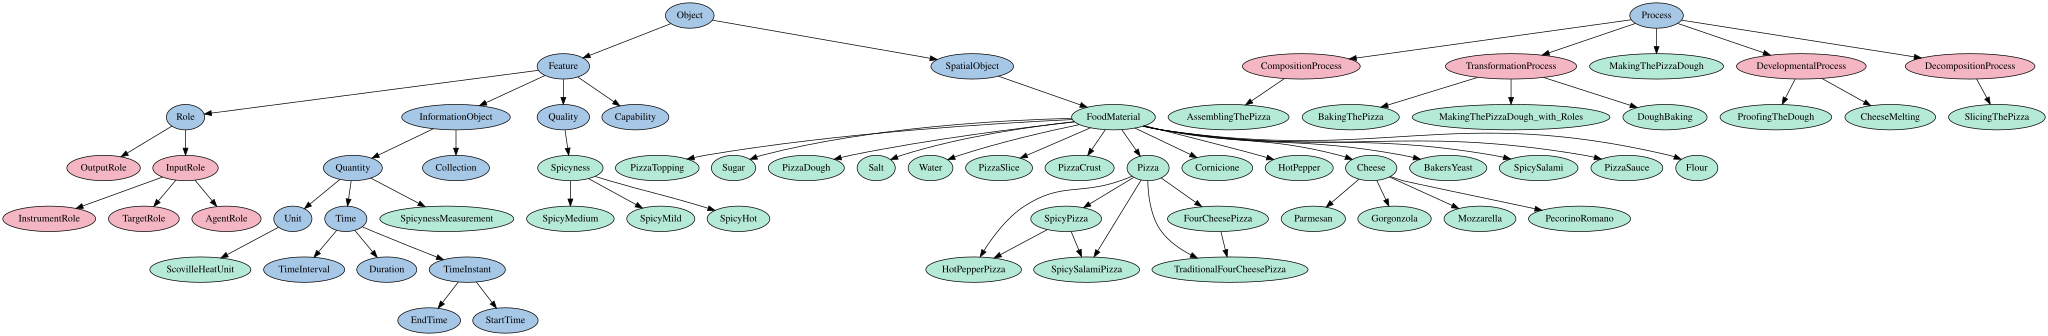

In [11]:
result = safe_call_reasoner(pizza)
if result["ok"]:
    n_inconsistent = len(result["inconsistent"])
    print(f"Ontology is consistent. Inconsistent classes: {n_inconsistent}")
else:
    print("Reasoner error:", result.get("error"))

import os
os.makedirs("dist", exist_ok=True)
pizza.save(file="dist/pizza-03.owl", format="rdfxml")
print("Saved pizza-03.owl")
display(get_color_tree([sulo, se, pizza]))

---

## Exercises

### Exercise 1 — `PackagingThePizza`
Model `PackagingThePizza` as a `se.CompositionProcess` that takes `PizzaSlice` (output of `SlicingThePizza`) and a `PizzaDeliveryBox` as inputs, producing a `PackagedPizza` (a new class you define) as output. Chain it after `SlicingThePizza` using `sulo:precedes`.



In [12]:
# Exercise 1 — your code here


### Exercise 2 — Chef as agent
Define `PizzaChef` as a subclass of `sulo:Role`. Using `se.AgentRole` and `sulo:isFeatureOf`, model the constraint that `MakingThePizzaDough` and `AssemblingThePizza` each have exactly one participant playing a `PizzaChef` role. Run the reasoner.



In [13]:
# Exercise 2 — your code here


### Exercise 3 — Raw vs baked pizza
The tutorial treats a raw assembled pizza and a baked pizza both as `pizza.Pizza`. Refine this model:
- Define `RawPizza` (assembled but not baked) and `BakedPizza` (result of `BakingThePizza`) as disjoint subclasses of `Pizza`.
- Update `AssemblingThePizza` so its output is a `RawPizza`.
- Update `BakingThePizza` so its input is a `RawPizza` and its output is a `BakedPizza`.
- Run the reasoner and check consistency.



In [14]:
# Exercise 3 — your code here
